# Azure Functions trace 2019

Two-week invocation counts (July 15–28, 2019) from [`data/azure2019`](data/azure2019). Each `invocations_per_function*.csv` file covers one day; columns `1`–`1440` are invocation counts per minute.

In [7]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("ggplot")

DATA_DIR = Path("data/azure2019")
TRACE_START = pd.Timestamp("2019-07-15", tz="UTC")
ID_COLS = ["HashOwner", "HashApp", "HashFunction", "Trigger"]

In [6]:
def load_invocations_per_minute(data_dir: Path = DATA_DIR) -> pd.DataFrame:
    """Sum invocations across all functions into one row per minute."""
    frames = []
    for path in sorted(data_dir.glob("invocations_per_function*.csv")):
        day = int(re.search(r"\.d(\d+)\.csv$", path.name).group(1))
        minute_counts = pd.read_csv(path, usecols=lambda c: c.isdigit()).sum(axis=0)
        minute_counts.index = minute_counts.index.astype(int)
        timestamps = (
            TRACE_START
            + pd.Timedelta(days=day - 1)
            + pd.to_timedelta(minute_counts.index - 1, unit="m")
        )
        frames.append(
            pd.DataFrame({"timestamp": timestamps, "count": minute_counts.values})
        )
    return (
        pd.concat(frames, ignore_index=True)
        .sort_values("timestamp")
        .reset_index(drop=True)
    )


df = load_invocations_per_minute()
df

,timestamp,count
0,2019-07-15 00:00:00+00:00,662592
1,2019-07-15 00:01:00+00:00,601633
2,2019-07-15 00:02:00+00:00,575989
3,2019-07-15 00:03:00+00:00,591299
4,2019-07-15 00:04:00+00:00,563383
...,...,...
20155,2019-07-28 23:55:00+00:00,611202
20156,2019-07-28 23:56:00+00:00,588891
20157,2019-07-28 23:57:00+00:00,578440
20158,2019-07-28 23:58:00+00:00,587982


<bound method NDFrame.head of timestamp
2019-07-15 00:00:00+00:00    32862030
2019-07-15 01:00:00+00:00    32746554
2019-07-15 02:00:00+00:00    34385569
2019-07-15 03:00:00+00:00    33641370
2019-07-15 04:00:00+00:00    34801510
                               ...   
2019-07-28 19:00:00+00:00    39336728
2019-07-28 20:00:00+00:00    38813980
2019-07-28 21:00:00+00:00    38925582
2019-07-28 22:00:00+00:00    38074656
2019-07-28 23:00:00+00:00    37146661
Freq: h, Name: count, Length: 336, dtype: int64>


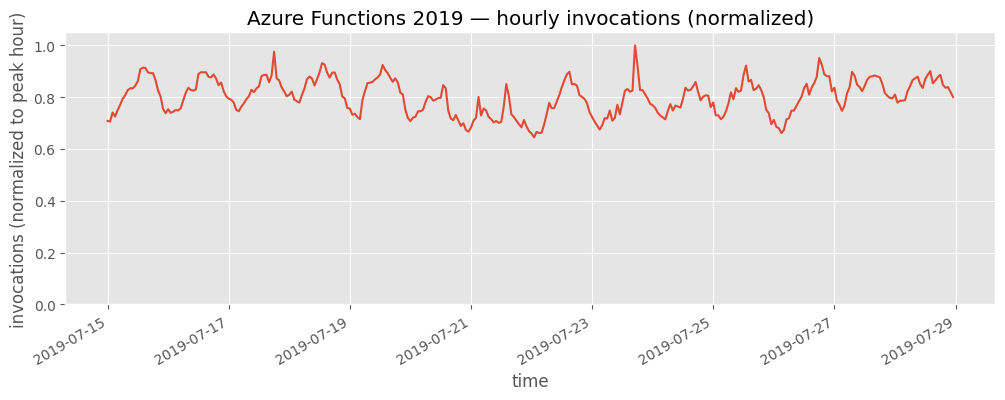

In [11]:
hourly = df.set_index("timestamp")["count"].resample("h").sum()
print(hourly.head)
hourly_norm = hourly / hourly.max()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hourly_norm.index, hourly_norm.values)
ax.set_xlabel("time")
ax.set_ylabel("invocations (normalized to peak hour)")
ax.set_ylim(0, 1.05)
ax.set_title("Azure Functions 2019 — hourly invocations (normalized)")
fig.autofmt_xdate()
plt.show()

In [9]:
def load_function_invocations(
    app: str,
    func: str,
    owner: str | None = None,
    data_dir: Path = DATA_DIR,
) -> pd.DataFrame:
    """Per-minute invocation counts for one function across all days."""
    frames = []
    for path in sorted(data_dir.glob("invocations_per_function*.csv")):
        day = int(re.search(r"\.d(\d+)\.csv$", path.name).group(1))
        day_df = pd.read_csv(path)
        mask = (day_df["HashApp"] == app) & (day_df["HashFunction"] == func)
        if owner is not None:
            mask &= day_df["HashOwner"] == owner
        rows = day_df.loc[mask, ID_COLS + [str(m) for m in range(1, 1441)]]
        if rows.empty:
            continue
        long = rows.melt(id_vars=ID_COLS, var_name="minute", value_name="count")
        long["minute"] = long["minute"].astype(int)
        long["timestamp"] = (
            TRACE_START
            + pd.Timedelta(days=day - 1)
            + pd.to_timedelta(long["minute"] - 1, unit="m")
        )
        frames.append(long.drop(columns="minute"))

    if not frames:
        raise ValueError(f"No rows found for app={app!r}, func={func!r}")

    return (
        pd.concat(frames, ignore_index=True)
        .sort_values("timestamp")
        .reset_index(drop=True)
    )